# 09 — Extracción de parches satelitales y normalización

Esta notebook cierra el bloque de preparación de datos satelitales. Su propósito es resolver tres problemas concretos que la notebook 10 necesita tener resueltos antes de construir el dataset de entrenamiento.

## Qué resuelve

**1. Mapeo estaciones → píxeles**
Cada estación IDEAM tiene coordenadas geográficas (lat, lon). La grilla GOES tiene 198 × 199 píxeles con su propia resolución y cobertura espacial. Para cada una de las 66 estaciones, esta notebook identifica el píxel más cercano en la grilla y verifica que un parche de 32×32 píxeles centrado en ese píxel quepa completamente dentro del dominio. El resultado es un archivo de mapeo que la notebook 10 usa para saber exactamente qué recortar de cada imagen.

**2. Parámetros de normalización z-score**
Las cinco bandas del ABI operan en rangos de temperatura de brillo distintos (~237 K en C08 vs ~273 K en C13), lo que introduciría un sesgo implícito en el aprendizaje de las capas convolucionales hacia las bandas de mayor varianza. Para evitarlo, cada banda se normaliza restando su media y dividiendo por su desviación estándar. Los parámetros se calculan exclusivamente sobre una muestra de 1.000 imágenes de 2024 (período de entrenamiento) y se aplican fijos sobre 2024 y 2025, sin recalcular sobre el set de prueba.

**3. Validación de la función de extracción**
Antes de que la notebook 10 use la función `extraer_parche()` sobre cientos de miles de timestamps, esta notebook la valida visualmente sobre dos casos contrastantes: un timestamp de madrugada sin actividad convectiva y un timestamp de tarde durante un evento de lluvia fuerte documentado. La diferencia entre ambos parches confirma que la función extrae correctamente la señal de interés.

## Por qué no se pre-extraen los parches

Pre-extraer todos los parches para las 66 estaciones y los ~105.000 timestamps disponibles requeriría aproximadamente 67 GB de almacenamiento solo para un lag temporal. En su lugar, esta notebook produce los insumos que permiten a la notebook 10 extraer parches on-the-fly durante la construcción del dataset, conservando únicamente los pares (estación, timestamp) que tienen tanto etiqueta válida como imagen satelital disponible.

## Outputs

| Archivo | Contenido |
|---|---|
| `estaciones_pixels.csv` | 66 filas: estación → (fila, columna) en la grilla GOES |
| `normalizacion_zscore.csv` | 5 filas: banda → (media, std) calculados sobre 2024 |
| `img-validacion_parches.png` | 3 estaciones × 5 bandas, timestamp de madrugada |
| `img-validacion_parches_convectivo.png` | 3 estaciones × 5 bandas, timestamp convectivo |

In [3]:
# Configuración --------------------------------------------------------------------
from pathlib import Path
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

RUTA_BASE  = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_SAT   = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_GT    = RUTA_BASE / "data_ingestion" / "ground_truth"
RUTA_CMIP  = RUTA_BASE / "data" / "cmip_cropped"

# Inputs del 07 y 08
INV_PATH   = RUTA_SAT / "inventario_goes.parquet"
COEF_PATH  = RUTA_SAT / "intercalibracion_coeficientes.csv"

# Rutas
GT_PATH  = RUTA_GT / "estaciones_ground_truth.csv"
COO_PATH = RUTA_GT / "estaciones_sabana_candidatas.csv"

# Estaciones finales (63) con sus coordenadas
gt   = pd.read_csv(GT_PATH)   # columna: estacion
coo  = pd.read_csv(COO_PATH)  # columnas: codigo, latitud, longitud

est  = gt.merge(
    coo[["codigo", "latitud", "longitud"]],
    left_on  = "estacion",
    right_on = "codigo",
    how      = "left"
)

# Verificación
sin_coord = est["latitud"].isna().sum()
print(f"Estaciones en ground truth : {len(gt)}")
print(f"Con coordenadas tras merge  : {len(est) - sin_coord}")
print(f"Sin coordenadas (advertencia): {sin_coord}")
if sin_coord > 0:
    print(est[est["latitud"].isna()][["estacion"]])
print(est[["estacion", "latitud", "longitud"]].head(3))

BANDAS     = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
HALF_SIZE  = 16    # parche de 32×32 píxeles (64×64 km a 2 km/px)
N_MUESTRA  = 1000  # imágenes de 2024 para calcular z-score
SEED       = 42

inv   = pd.read_parquet(INV_PATH)
coef  = pd.read_csv(COEF_PATH).set_index("banda")["offset_K"]  # todos cero

print(f"\nInventario: {len(inv):,} timestamps")
print(f"Estaciones con coordenadas: {len(est)}")

Estaciones en ground truth : 66
Con coordenadas tras merge  : 66
Sin coordenadas (advertencia): 0
   estacion  latitud  longitud
0  21201980  4.59157 -74.05471
1  21202180  4.54311 -74.15601
2  21202190  4.51872 -74.08867

Inventario: 104,910 timestamps
Estaciones con coordenadas: 66


In [4]:
# Grilla GOES: cargar lat/lon de referencia ----------------------------------------
# # Leer un archivo cualquiera para extraer la grilla lat/lon
filepath_ref = inv.iloc[0]["filepath"]
ds_ref = xr.open_dataset(filepath_ref)

lat_grid = ds_ref["lat"].values   # shape (198,)
lon_grid = ds_ref["lon"].values   # shape (199,)
ds_ref.close()

print(f"Grilla GOES:")
print(f"  lat: {lat_grid.min():.3f}° → {lat_grid.max():.3f}°  ({len(lat_grid)} píxeles)")
print(f"  lon: {lon_grid.min():.3f}° → {lon_grid.max():.3f}°  ({len(lon_grid)} píxeles)")
print(f"  Resolución aprox: {abs(np.diff(lat_grid).mean())*111:.2f} km/px")

Grilla GOES:
  lat: 2.802° → 6.391°  (198 píxeles)
  lon: -75.880° → -72.287°  (199 píxeles)
  Resolución aprox: 2.02 km/px


In [8]:
# Mapeo estaciones → píxeles -------------------------------------------------------
def encontrar_pixel(lat_est, lon_est, lat_grid, lon_grid):
    """Devuelve (fila, columna) del píxel más cercano a la estación."""
    fila = int(np.argmin(np.abs(lat_grid - lat_est)))
    col  = int(np.argmin(np.abs(lon_grid - lon_est)))
    return fila, col

def verificar_margen(fila, col, half_size, nrows, ncols):
    """Comprueba que el parche centrado en (fila, col) cabe en la grilla."""
    return (
        fila >= half_size and fila < nrows - half_size and
        col  >= half_size and col  < ncols - half_size
    )

nrows, ncols = len(lat_grid), len(lon_grid)
registros = []

for _, row in est.iterrows():
    fila, col = encontrar_pixel(row["latitud"], row["longitud"],
                                lat_grid, lon_grid)
    en_margen = verificar_margen(fila, col, HALF_SIZE, nrows, ncols)
    lat_px = lat_grid[fila]
    lon_px = lon_grid[col]
    dist_km = np.sqrt(
        ((row["latitud"]  - lat_px) * 111) ** 2 +
        ((row["longitud"] - lon_px) * 111 * np.cos(np.radians(row["latitud"]))) ** 2
    )
    registros.append({
        "codigoestacion": row["estacion"],
        "lat_est" : row["latitud"],
        "lon_est" : row["longitud"],
        "fila"    : fila,
        "col"     : col,
        "lat_px"  : lat_px,
        "lon_px"  : lon_px,
        "dist_km" : round(dist_km, 3),
        "en_margen": en_margen,
    })

df_pixels = pd.DataFrame(registros)

print(f"Estaciones mapeadas    : {len(df_pixels)}")
print(f"  Dentro del margen    : {df_pixels['en_margen'].sum()}")
print(f"  Fuera del margen     : {(~df_pixels['en_margen']).sum()}")
print(f"\nDistancia estación → píxel (km):")
print(df_pixels["dist_km"].describe().round(3))
print(f"\nEstaciones fuera del margen (si las hay):")
print(df_pixels[~df_pixels["en_margen"]][["codigoestacion","lat_est","lon_est"]])

Estaciones mapeadas    : 66
  Dentro del margen    : 66
  Fuera del margen     : 0

Distancia estación → píxel (km):
count    66.000
mean      0.746
std       0.279
min       0.106
25%       0.530
50%       0.784
75%       0.980
max       1.182
Name: dist_km, dtype: float64

Estaciones fuera del margen (si las hay):
Empty DataFrame
Columns: [codigoestacion, lat_est, lon_est]
Index: []


**Resultados del mapeo**

Las 66 estaciones de ground truth se mapearon exitosamente a la grilla GOES. Ninguna quedó fuera del margen de extracción de parches (32×32 píxeles), lo que confirma que el dominio satelital cubre con holgura la red de observación disponible.

_En kilómetros, 32 píxeles × 2.02 km/px ≈ 64×64 km de contexto espacial alrededor de cada estación. Ese es el campo visual que el modelo tendrá para cada predicción._

La distancia entre cada estación y su píxel asignado tiene una mediana de 0.78 km y un máximo de 1.18 km — valores inferiores a la resolución efectiva del sensor (2.02 km/px) y al desplazamiento de paralaje máximo documentado en la notebook 06 (1.37 km). El error de posicionamiento estación-píxel es, en todos los casos, sub-píxel y no requiere tratamiento adicional.

In [9]:
# Parámetros z-score (solo 2024) ---------------------------------------------------
# Muestreo aleatorio de imágenes de 2024
inv_2024 = inv[inv["satelite"] == "G16"].sample(N_MUESTRA, random_state=SEED)

acumulados = {b: [] for b in BANDAS}

for _, fila in tqdm(inv_2024.iterrows(), total=N_MUESTRA,
                    desc="Calculando z-score"):
    try:
        ds = xr.open_dataset(fila["filepath"])
        for banda in BANDAS:
            vals = ds[banda].values.flatten()
            vals = vals[~np.isnan(vals)]
            acumulados[banda].append(vals)
        ds.close()
    except Exception as e:
        print(f"[ERROR] {fila['filepath']}: {e}")

# Calcular media y std globales por banda
zscore_params = []
for banda in BANDAS:
    todos = np.concatenate(acumulados[banda])
    zscore_params.append({
        "banda": banda,
        "mean" : round(float(todos.mean()), 4),
        "std"  : round(float(todos.std()),  4),
        "n_px" : len(todos),
    })

df_zscore = pd.DataFrame(zscore_params)
print(df_zscore.to_string(index=False))

Calculando z-score:   3%|▎         | 30/1000 [00:00<00:23, 41.86it/s]

[ERROR] C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20240708-131000.nc: "No variable named 'CMI_C09'. Did you mean one of ('CMI_C08', 'CMI_C14', 'CMI_C13')?"


Calculando z-score:  46%|████▌     | 462/1000 [00:09<00:10, 49.86it/s]

[ERROR] C:\Users\diani\Documents\repositories\nowcasting-bogota\data\cmip_cropped\CMIPC_20240928-172000.nc: "No variable named 'CMI_C09'. Did you mean one of ('CMI_C08',)?"


Calculando z-score: 100%|██████████| 1000/1000 [00:20<00:00, 48.73it/s]


  banda     mean     std     n_px
CMI_C08 236.7736  8.1321 39362598
CMI_C09 244.5560 10.1258 39323196
CMI_C10 252.0979 11.9488 39323196
CMI_C13 272.8473 20.1850 39323196
CMI_C14 271.5042 20.3784 39323196


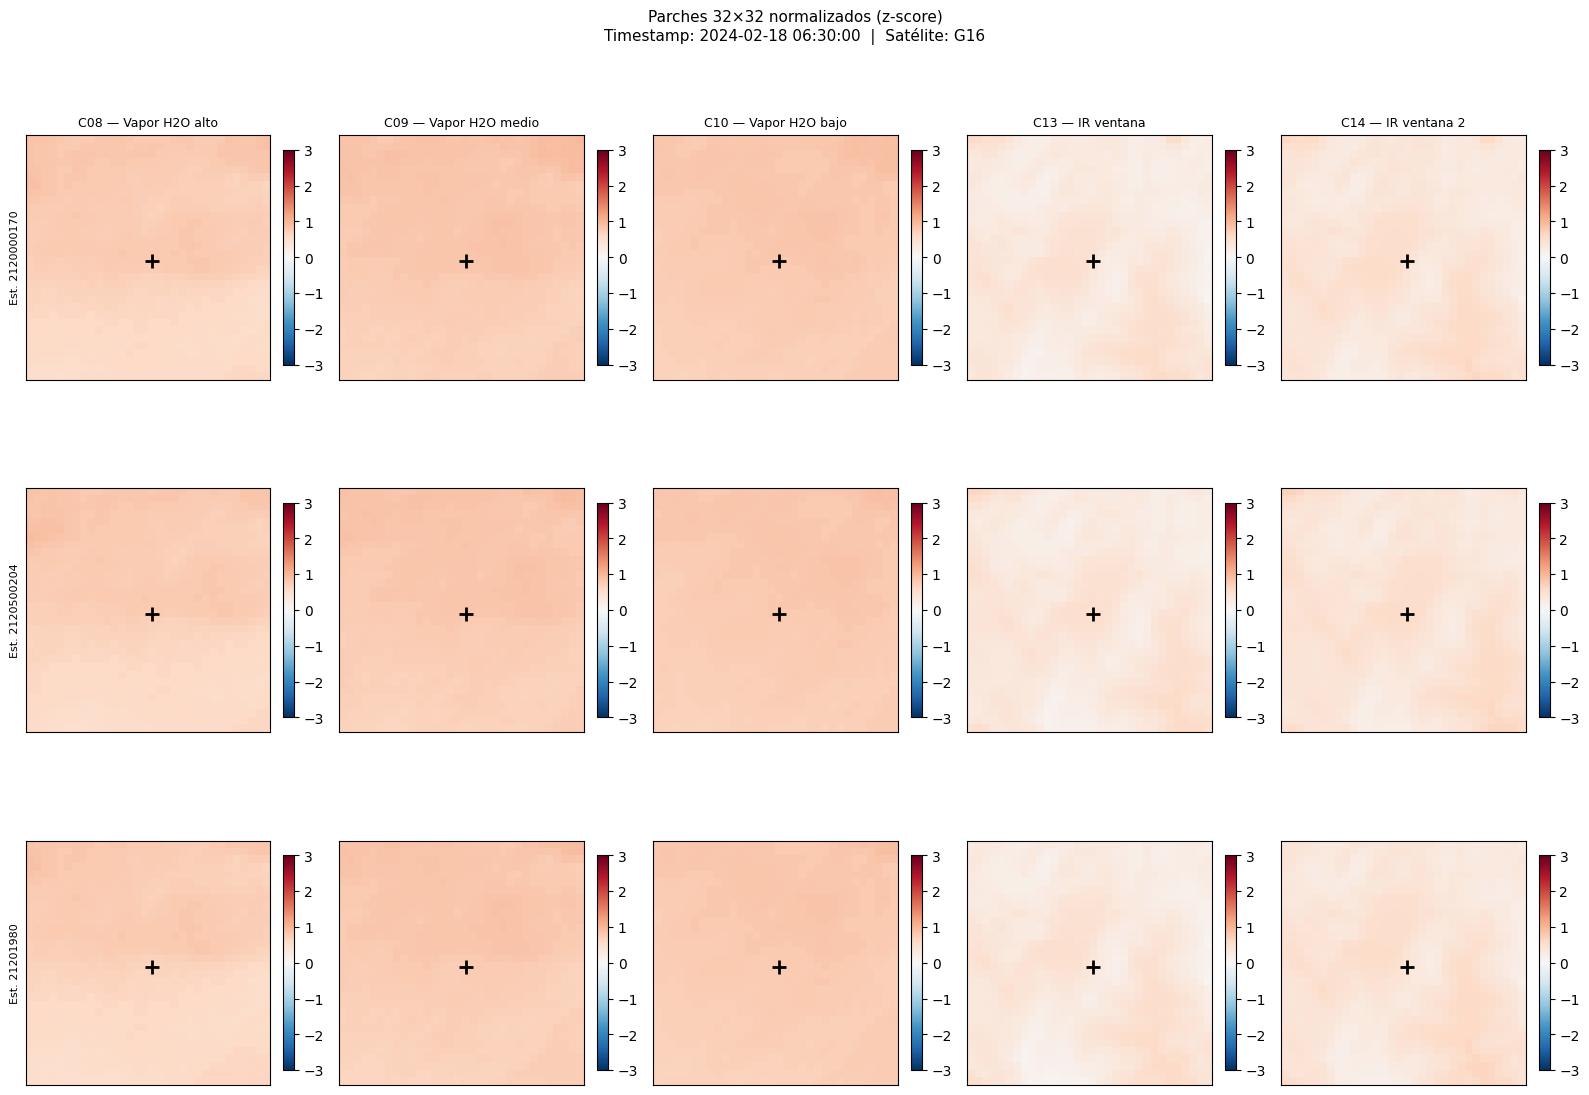

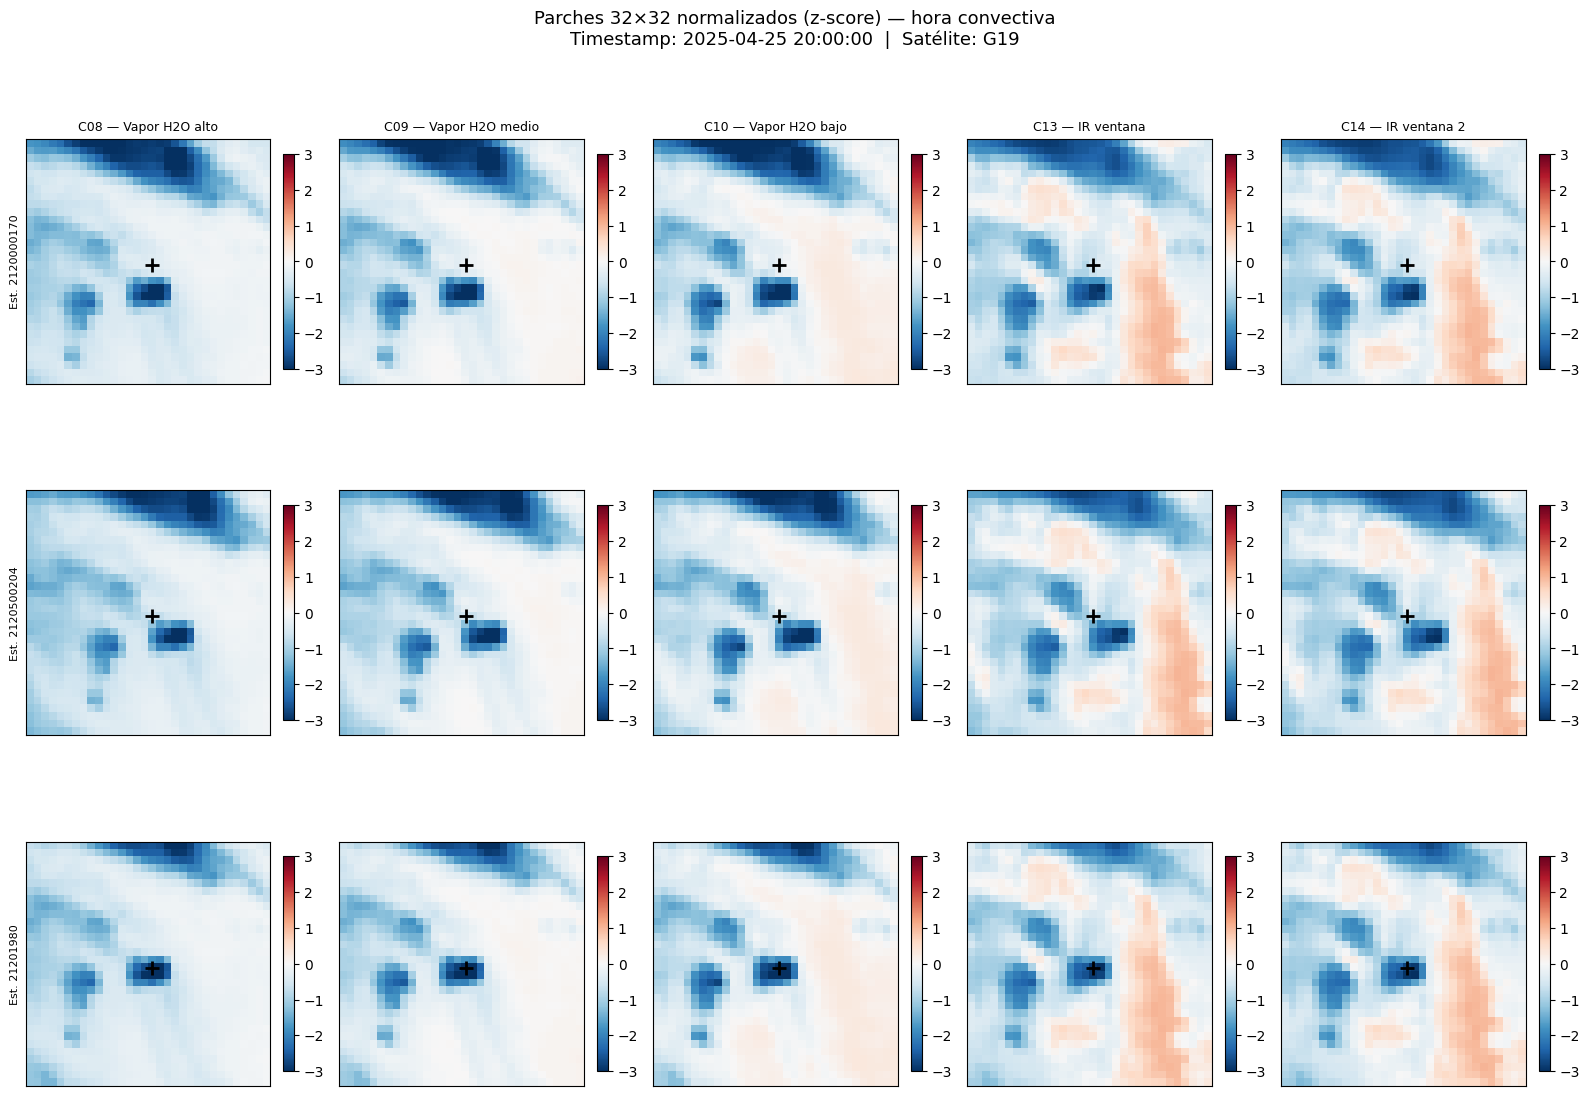


Rango z-score en los 3 parches de prueba:
  Min: 0.07  Max: 0.93
  (Esperado: mayoría entre -3 y +3; valores extremos = nube convectiva intensa)


In [ ]:
# Función de extracción y validación visual ----------------------------------------
def extraer_parche(filepath, fila_centro, col_centro,
                   half_size, bandas, zscore_params):
    """
    Lee un archivo CMIPC y extrae un parche espacial centrado en
    (fila_centro, col_centro), normalizado por z-score.

    Retorna array de shape (len(bandas), 2*half_size, 2*half_size).
    """
    ds = xr.open_dataset(filepath)
    f0, f1 = fila_centro - half_size, fila_centro + half_size
    c0, c1 = col_centro  - half_size, col_centro  + half_size

    parche = np.stack([
        ds[banda].values[f0:f1, c0:c1]
        for banda in bandas
    ], axis=0).astype(np.float32)   # (B, H, W)
    ds.close()

    # Z-score por banda
    for i, banda in enumerate(bandas):
        mean = zscore_params.loc[zscore_params["banda"] == banda, "mean"].values[0]
        std  = zscore_params.loc[zscore_params["banda"] == banda, "std"].values[0]
        parche[i] = (parche[i] - mean) / std

    return parche


# ── Validación visual: 3 estaciones × 5 bandas ─────────────────────────────
est_muestra = df_pixels[df_pixels["en_margen"]].sample(3, random_state=SEED)
ts_prueba   = inv[inv["satelite"] == "G16"].sample(1, random_state=SEED).iloc[0]

TITULOS_BANDA = {
    "CMI_C08": "C08 — Vapor H2O alto",
    "CMI_C09": "C09 — Vapor H2O medio",
    "CMI_C10": "C10 — Vapor H2O bajo",
    "CMI_C13": "C13 — IR ventana",
    "CMI_C14": "C14 — IR ventana 2",
}

fig, axes = plt.subplots(
    len(est_muestra), len(BANDAS),
    figsize=(16, 4 * len(est_muestra))
)

for i, (_, est_row) in enumerate(est_muestra.iterrows()):
    parche = extraer_parche(
        ts_prueba["filepath"],
        int(est_row["fila"]), int(est_row["col"]),
        HALF_SIZE, BANDAS, df_zscore
    )
    for j, banda in enumerate(BANDAS):
        ax = axes[i][j]
        im = ax.imshow(parche[j], cmap="RdBu_r", vmin=-3, vmax=3)
        if i == 0:
            ax.set_title(TITULOS_BANDA[banda], fontsize=9)
        if j == 0:
            ax.set_ylabel(f"Est. {est_row['codigoestacion']}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        # Marcar centro de la estación
        ax.plot(HALF_SIZE, HALF_SIZE, "k+", markersize=10, markeredgewidth=2)
        plt.colorbar(im, ax=ax, fraction=0.04)

fig.suptitle(
    f"Parches 32×32 normalizados (z-score)\n"
    f"Timestamp: {ts_prueba['timestamp']}  |  Satélite: {ts_prueba['satelite']}",
    fontsize=11
)
plt.tight_layout()
plt.savefig(RUTA_SAT / "img-validacion_parches.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Validación visual 2: timestamp convectivo (tarde) ──────────────────────
ts_prueba2 = inv[
    (inv["timestamp"] >= "2025-04-25 20:00") &
    (inv["timestamp"] <= "2025-04-25 21:00")
].iloc[0]

fig2, axes2 = plt.subplots(
    len(est_muestra), len(BANDAS),
    figsize=(16, 4 * len(est_muestra))
)

for i, (_, est_row) in enumerate(est_muestra.iterrows()):
    parche2 = extraer_parche(
        ts_prueba2["filepath"],
        int(est_row["fila"]), int(est_row["col"]),
        HALF_SIZE, BANDAS, df_zscore
    )
    for j, banda in enumerate(BANDAS):
        ax = axes2[i][j]
        im = ax.imshow(parche2[j], cmap="RdBu_r", vmin=-3, vmax=3)
        if i == 0:
            ax.set_title(TITULOS_BANDA[banda], fontsize=9)
        if j == 0:
            ax.set_ylabel(f"Est. {est_row['codigoestacion']}", fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.plot(HALF_SIZE, HALF_SIZE, "k+", markersize=10, markeredgewidth=2)
        plt.colorbar(im, ax=ax, fraction=0.04)

fig2.suptitle(
    f"Parches 32×32 normalizados (z-score) — hora convectiva\n"
    f"Timestamp: {ts_prueba2['timestamp']}  |  Satélite: {ts_prueba2['satelite']}",
    fontsize=13
)
plt.tight_layout()
plt.savefig(RUTA_SAT / "img-validacion_parches_convectivo.png", dpi=150, bbox_inches="tight")
plt.show()

# Verificación numérica
print(f"\nRango z-score en los 3 parches de prueba:")
print(f"  Min: {parche.min():.2f}  Max: {parche.max():.2f}")
print(f"  (Esperado: mayoría entre -3 y +3; valores extremos = nube convectiva intensa)")

**Validación visual — interpretación**

Los dos timestamps de prueba ilustran los dos extremos del espacio de señales que el modelo debe aprender a distinguir.

**Timestamp de madrugada (2024-02-18, 06:30 UTC — 1:30 AM hora local)** Las cinco bandas muestran valores uniformemente positivos (naranja), sin estructura espacial apreciable. A esa hora no hay forzamiento solar y la atmósfera sobre la Sabana se encuentra en reposo térmico: sin convección activa, sin acumulación anómala de vapor de agua, sin cimas de nubes frías.
Este es el caso negativo típico que el modelo verá en la mayoría de los timestamps del dataset.

**Timestamp convectivo (2025-04-25, 20:00 UTC — 3:00 PM hora local)** El contraste es inmediato. Las bandas de vapor de agua (C08, C09, C10) muestran valores profundamente negativos en todo el dominio — la troposfera está saturada de humedad en todos los niveles, una señal de convergencia regional que Casallas-García et al. (2023) identifican como precursora del desarrollo convectivo sobre la Sabana. Las bandas infrarrojas (C13, C14) revelan la convección ya organizada: manchas azul intenso (z-score ~ −3, equivalente a temperaturas de brillo de ~210 K) corresponden a cimas de nubes convectivas profundas que alcanzan ~12 km de altura; el naranja intercalado corresponde a superficie o nubosidad baja visible entre las células. Las tres estaciones muestran el mismo sistema convectivo desde distintos ángulos — la mancha aparece en posiciones relativas diferentes respecto al centro de cada parche, lo que refleja la ubicación geográfica distinta de cada estación dentro del evento.

La diferencia entre estos dos parches — un campo homogéneo sin señal versus una estructura espacial rica en las cinco bandas — es precisamente lo que el modelo ResNet debe aprender a leer para anticipar lluvia fuerte con hasta tres horas de anticipación.

In [16]:
# Exportación ----------------------------------------------------------------------
# Guardar solo estaciones dentro del margen
df_pixels_final = df_pixels[df_pixels["en_margen"]].copy()

px_path     = RUTA_SAT / "estaciones_pixels.csv"
zscore_path = RUTA_SAT / "normalizacion_zscore.csv"

df_pixels_final.to_csv(px_path,     index=False)
df_zscore.to_csv(zscore_path,        index=False)

print(f"Estaciones mapeadas exportadas : {px_path}  ({len(df_pixels_final)} filas)")
print(f"Parámetros z-score exportados  : {zscore_path}  ({len(df_zscore)} bandas)")
print(f"\nResumen:")
print(f"  Parche: {2*HALF_SIZE}×{2*HALF_SIZE} px  (~{2*HALF_SIZE*2:.0f}×{2*HALF_SIZE*2:.0f} km)")
print(f"  Bandas: {BANDAS}")
print(f"  Z-score calculado sobre: {N_MUESTRA} imágenes de 2024 (G16)")
print(f"  Offset de intercalibración: todos cero (ver 08)")

Estaciones mapeadas exportadas : C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\estaciones_pixels.csv  (66 filas)
Parámetros z-score exportados  : C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\normalizacion_zscore.csv  (5 bandas)

Resumen:
  Parche: 32×32 px  (~64×64 km)
  Bandas: ['CMI_C08', 'CMI_C09', 'CMI_C10', 'CMI_C13', 'CMI_C14']
  Z-score calculado sobre: 1000 imágenes de 2024 (G16)
  Offset de intercalibración: todos cero (ver 08)
